# Notebook 7: Combinación de datos reales y sintéticos

**Objetivo:** preparar, para el predictor de covarianzas, conjuntos
de entrenamiento que combinan los retornos reales con los generados por los
notebooks 3-6 (ruido, Gaussiana, VAE, autorregresivo) — en distintas
cantidades — para poder responder la pregunta central del taller que
motiva este proyecto: **¿mejora el modelo si además de datos reales le
damos datos sintéticos?**

**Este notebook NO combina los retornos en sí.** Los datasets sintéticos
no son periodos nuevos de tiempo — son realizaciones alternativas de las
MISMAS fechas exactas que el histórico real (comprobado más abajo). Lo
que se combina aquí son los **ejemplos ya construidos** (ventana histórica
→ Sigma), generados por separado a partir de cada fuente, y después
juntados — manteniendo validación y test siempre 100% reales.

**Los 4 generadores no se usan todos de la misma forma**, porque cada uno
está construido para un propósito distinto (ver la celda de cada sección
para el detalle):
- **Ruido y Gaussiana** (Notebooks 3-4): ya generan una serie de retornos
  completa y lista para usar — se cargan directamente.
- **Autorregresivo** (Notebook 6): está entrenado para generar EL FUTURO
  a partir de una historia — se usa para sintetizar horizontes alternativos
  de 42 días, manteniendo la historia de entrada 100% real.
- **VAE** (Notebook 5): sus propios generadores se guardaron con
  `"intended_use": "local counterfactual editor for covariance-prediction
  data augmentation"` — están pensados para editar tramos cortos (5, 7 o
  10 días), no para generar series completas. Se usa para perturbar un
  tramo corto DENTRO de la historia de entrada, manteniendo el futuro
  (la Sigma objetivo) 100% real.

In [61]:
import sys
sys.path.append('..')

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch

from src.predictor.windowing import build_covariance_windows, summarize_windows
from src.predictor.split import temporal_split_purged
from src.factors.decomposition import reconstruct_returns
from src.generators.vae import build_component_frame, GRUVAE, decode_latent_variants
from src.generators.autoregressive import ProbabilisticMultiHorizonGRU, generate_multihorizon_rolling_batch

## 1. Cargar los retornos reales y los sintéticos ya disponibles

In [62]:
returns_real = pd.read_parquet("../data/processed/returns_daily.parquet")
returns_noise = pd.read_parquet("../data/processed/returns_synthetic_noise.parquet")
returns_gaussian = pd.read_parquet("../data/processed/returns_synthetic_gaussian.parquet")

fuentes = {"real": returns_real, "noise": returns_noise, "gaussian": returns_gaussian}
for nombre, df in fuentes.items():
    print(f"{nombre:10s}: shape={df.shape}, {df.index.min().date()} -> {df.index.max().date()}")

real      : shape=(2785, 30), 2015-01-05 -> 2026-01-30
noise     : shape=(2785, 30), 2015-01-05 -> 2026-01-30
gaussian  : shape=(2785, 30), 2015-01-05 -> 2026-01-30


## 2. Por qué no se pueden concatenar como series temporales

Comprobación explícita: mismas fechas exactas, no periodos distintos.

In [63]:
print("Mismas columnas (activos) que el real:")
print(f"  noise:    {list(returns_real.columns) == list(returns_noise.columns)}")
print(f"  gaussian: {list(returns_real.columns) == list(returns_gaussian.columns)}")
print()
print("Mismas fechas exactas que el real:")
print(f"  noise:    {(returns_real.index == returns_noise.index).all()}")
print(f"  gaussian: {(returns_real.index == returns_gaussian.index).all()}")
print()
print("Cada fuente sintética es una realización alternativa del mismo calendario,")
print("no un periodo nuevo — por eso se combinan a nivel de EJEMPLO, no de serie.")

Mismas columnas (activos) que el real:
  noise:    True
  gaussian: True

Mismas fechas exactas que el real:
  noise:    True
  gaussian: True

Cada fuente sintética es una realización alternativa del mismo calendario,
no un periodo nuevo — por eso se combinan a nivel de EJEMPLO, no de serie.


## 3. Construir ventanas por separado en cada fuente

Se usa la misma configuración de referencia que el predictor de
covarianzas: `history_days=504, horizon_days=42, step_days=5`. Si esa
configuración cambia más adelante, hay que actualizarla aquí también
para que los ejemplos combinados sigan siendo compatibles.

In [64]:
HISTORY_DAYS = 504
HORIZON_DAYS = 42
STEP_DAYS = 5

windows_real = build_covariance_windows(returns_real, history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS)
windows_noise = build_covariance_windows(returns_noise, history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS)
windows_gaussian = build_covariance_windows(returns_gaussian, history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS)

n_assets = returns_real.shape[1]
for nombre, w in [("real", windows_real), ("noise", windows_noise), ("gaussian", windows_gaussian)]:
    print(f"{nombre:10s}: {summarize_windows(w, n_assets)}")

real      : {'n_ejemplos': 448, 'shape_X_por_ejemplo': (504, 30), 'shape_y_por_ejemplo': (30, 30), 'primera_fecha_corte': Timestamp('2017-01-04 00:00:00'), 'ultima_fecha_corte': Timestamp('2025-11-24 00:00:00')}
noise     : {'n_ejemplos': 448, 'shape_X_por_ejemplo': (504, 30), 'shape_y_por_ejemplo': (30, 30), 'primera_fecha_corte': Timestamp('2017-01-04 00:00:00'), 'ultima_fecha_corte': Timestamp('2025-11-24 00:00:00')}
gaussian  : {'n_ejemplos': 448, 'shape_X_por_ejemplo': (504, 30), 'shape_y_por_ejemplo': (30, 30), 'primera_fecha_corte': Timestamp('2017-01-04 00:00:00'), 'ultima_fecha_corte': Timestamp('2025-11-24 00:00:00')}


## 4. Split temporal purgado — solo sobre las ventanas reales

Validación y test deben ser siempre datos reales: es lo único que
representa de verdad "lo que pasó". Los sintéticos, al ser realizaciones
alternativas y no observaciones, solo tiene sentido usarlos para
aumentar el ENTRENAMIENTO.

**Por qué hace falta "purgar" además de separar train/test:** cada
ejemplo abarca `history_days + horizon_days` = 546 días de calendario (504
hacia atrás + 42 hacia adelante desde su fecha de corte), no solo el día
del corte. Si el último ejemplo de entrenamiento y el primero de test
quedan a pocos días de distancia, sus 546 días se solapan casi por
completo — el ejemplo de entrenamiento calcularía su Sigma usando
retornos reales de fechas que caen DENTRO de lo que el ejemplo de test
está intentando predecir. Sin purgar, el modelo vería (indirectamente,
a través del objetivo de entrenamiento) la respuesta antes de que se le
pregunte. `temporal_split_purged` elimina los últimos ejemplos de
entrenamiento que queden a menos de 546 días del primer ejemplo de test,
para garantizar un hueco real entre lo que el modelo entrena y lo que se
usa para evaluarlo.

In [65]:
split_test_real = temporal_split_purged(
    windows_real, test_fraction=0.2,
    history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS,
)
windows_train_only_real = {
    "X": split_test_real["X_train"], "y": split_test_real["y_train"], "cutoff_dates": split_test_real["dates_train"],
}
split_val_real = temporal_split_purged(
    windows_train_only_real, test_fraction=0.2,
    history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS,
)

X_train_real, y_train_real, dates_train_real = split_val_real["X_train"], split_val_real["y_train"], split_val_real["dates_train"]
X_val_real, y_val_real = split_val_real["X_test"], split_val_real["y_test"]
X_test_real, y_test_real = split_test_real["X_test"], split_test_real["y_test"]

# Última fecha de corte segura para entrenamiento (ya purgada frente a val Y test)
ultima_fecha_train_segura = max(dates_train_real)

print(f"Entrenamiento (real): {len(X_train_real)} ejemplos, hasta {ultima_fecha_train_segura.date()}")
print(f"Validación (real):    {len(X_val_real)} ejemplos")
print(f"Test (real):          {len(X_test_real)} ejemplos")

Entrenamiento (real): 88 ejemplos, hasta 2018-09-26
Validación (real):    50 ejemplos
Test (real):          90 ejemplos


## 5. Filtrar las ventanas sintéticas: solo aportan a entrenamiento

Se descarta cualquier ejemplo sintético cuya fecha de corte caiga en o
después de la zona de validación/test real — así ningún ejemplo sintético
puede solapar temporalmente con lo que se usa para evaluar, aunque sus
valores sean simulados.

In [66]:
def filtrar_para_entrenamiento(windows, fecha_limite):
    X_filtrado, y_filtrado = [], []
    for x, y, fecha in zip(windows["X"], windows["y"], windows["cutoff_dates"]):
        if fecha <= fecha_limite:
            X_filtrado.append(x)
            y_filtrado.append(y)
    return X_filtrado, y_filtrado

X_noise_train, y_noise_train = filtrar_para_entrenamiento(windows_noise, ultima_fecha_train_segura)
X_gaussian_train, y_gaussian_train = filtrar_para_entrenamiento(windows_gaussian, ultima_fecha_train_segura)

print(f"Ejemplos sintéticos utilizables para entrenamiento:")
print(f"  noise:    {len(X_noise_train)}")
print(f"  gaussian: {len(X_gaussian_train)}")

Ejemplos sintéticos utilizables para entrenamiento:
  noise:    88
  gaussian: 88


## 6. Autorregresivo (AR): generar futuros alternativos

El modelo AR (`final_models/autoregressive/multihorizon_5d/`) está
entrenado para predecir varios días seguidos a partir de un contexto
reciente — es, literalmente, un generador de futuros. Por eso se usa así:
para cada ejemplo real de entrenamiento, se mantiene su historia de 504
días **sin tocar**, y se genera con el AR un horizonte alternativo de 42
días (el mismo tamaño que `HORIZON_DAYS`) a partir del contexto real que
lo precede. La Sigma objetivo se recalcula sobre ese futuro sintético.

El AR opera sobre los 61 componentes factoriales (mercado + 30 sectoriales
+ 30 idiosincráticos, el mismo formato del Notebook 2/6), no sobre los 30
retornos directamente — hay que componerlos, generar, y reconstruir los
retornos con `reconstruct_returns` antes de poder calcular la Sigma.

Se generan **2 temperaturas** (1.0 y 1.3, para variar la dispersión del
muestreo) por cada ejemplo real — duplicando el número de ejemplos que
aporta esta fuente.

In [67]:
market_factor = pd.read_parquet("../data/processed/market_factor.parquet")["market_factor"]
sector_factors = pd.read_parquet("../data/processed/sector_factors.parquet")
idiosyncratic = pd.read_parquet("../data/processed/idiosyncratic_returns.parquet")
betas = pd.read_parquet("../data/processed/factor_betas.parquet")

components = build_component_frame(market_factor, sector_factors, idiosyncratic)
feature_names = list(components.columns)

def split_components(frame):
    return frame.iloc[:, 0], frame.iloc[:, 1:31], frame.iloc[:, 31:61]

DEVICE = "cpu"
AR_DIR = Path("../final_models/autoregressive/multihorizon_5d")
ar_config = json.loads((AR_DIR / "config.json").read_text())
ar_model = ProbabilisticMultiHorizonGRU(
    input_dim=ar_config["input_dim"], prediction_horizon=ar_config["prediction_horizon"],
    hidden_dims=ar_config["hidden_dims"], dropout=ar_config["dropout"],
)
payload = torch.load(AR_DIR / "model.pt", map_location=DEVICE, weights_only=False)
ar_model.load_state_dict(payload["model_state_dict"])
ar_model.eval()
ar_scaler = joblib.load(AR_DIR / "scaler.joblib")
AR_CONTEXT_LENGTH = ar_config["context_length"]
AR_TEMPERATURES = [1.0, 1.3]

X_ar_train, y_ar_train = [], []
for i, fecha_corte in enumerate(dates_train_real):
    idx_corte = components.index.get_loc(fecha_corte)
    contexto = components.iloc[idx_corte - AR_CONTEXT_LENGTH: idx_corte]
    contexto_norm = ar_scaler.transform(contexto.to_numpy()).astype(np.float32)

    for temperatura in AR_TEMPERATURES:
        generado, _, _ = generate_multihorizon_rolling_batch(
            ar_model, contexto_norm, generation_horizon=HORIZON_DAYS,
            temperature=temperatura, n_paths=1, seed=42 + i, device=DEVICE,
        )
        generado_denorm = ar_scaler.inverse_transform(generado[0])
        gen_frame = pd.DataFrame(generado_denorm, columns=feature_names)
        mkt, sec, idio = split_components(gen_frame)
        retornos_sinteticos = reconstruct_returns(mkt, sec, idio, betas)
        sigma_sintetica = np.cov(retornos_sinteticos.to_numpy(), rowvar=False)

        X_ar_train.append(X_train_real[i])
        y_ar_train.append(sigma_sintetica)

autovalores_min = [np.linalg.eigvalsh(s).min() for s in y_ar_train]
print(f"Ejemplos generados con AR: {len(X_ar_train)}")
print(f"Autovalor mínimo entre todas las Sigma generadas: {min(autovalores_min):.2e} (debe ser >= 0)")

Ejemplos generados con AR: 176
Autovalor mínimo entre todas las Sigma generadas: 1.47e-06 (debe ser >= 0)


## 7. VAE: editar tramos de la historia

A diferencia del AR, los generadores del VAE (`final_models/vae/`) están
entrenados sobre ventanas cortas (5, 7 y 10 días) y no cubren un horizonte
de 42 días de una vez. Por eso se usan al revés que el AR: se mantiene el
**futuro real sin tocar** (la Sigma objetivo sigue siendo la real), y se
edita un tramo corto y aleatorio DENTRO de los 504 días de historia de
entrada, usando la función `decode_latent_variants` (codifica el tramo
real, lo perturba en el espacio latente, lo decodifica).

Se reparte el uso de los 3 generadores (ventanas de 5, 7 y 10 días) entre
los ejemplos para dar variedad, con `alpha=1.0` (intensidad de la
perturbación) — la misma configuración que la evaluación generativa del
propio Notebook 5 consideró un buen equilibrio.

In [68]:
vae_registry = pd.read_csv("../final_models/vae/model_registry.csv")

vae_models = {}
for _, row in vae_registry.iterrows():
    cfg = json.loads((Path("..") / row["config_path"]).read_text())
    modelo = GRUVAE(input_dim=cfg["input_dim"], hidden_dims=cfg["hidden_dims"], latent_dim=cfg["latent_dim"], dropout=cfg["dropout"])
    payload = torch.load(Path("..") / row["model_path"], map_location=DEVICE, weights_only=False)
    modelo.load_state_dict(payload["model_state_dict"])
    modelo.eval()
    escalador = joblib.load(Path("..") / row["scaler_path"])
    vae_models[int(row["window_size"])] = {"model": modelo, "scaler": escalador}

print(f"Generadores VAE cargados (tamaños de ventana): {sorted(vae_models.keys())}")

VAE_ALPHA = 1.0
rng_vae = np.random.default_rng(42)
tamanos_ventana = list(vae_models.keys())

X_vae_train, y_vae_train = [], []
for i, fecha_corte in enumerate(dates_train_real):
    idx_corte = components.index.get_loc(fecha_corte)
    window_size = tamanos_ventana[i % len(tamanos_ventana)]
    vae_info = vae_models[window_size]

    pos_relativa = int(rng_vae.integers(0, HISTORY_DAYS - window_size))
    idx_inicio = idx_corte - HISTORY_DAYS + pos_relativa

    segmento_real = components.iloc[idx_inicio: idx_inicio + window_size]
    segmento_norm = vae_info["scaler"].transform(segmento_real.to_numpy()).astype(np.float32)

    variantes = decode_latent_variants(vae_info["model"], segmento_norm, [VAE_ALPHA], seed=42 + i, device=DEVICE)
    segmento_editado = vae_info["scaler"].inverse_transform(variantes[VAE_ALPHA])
    seg_frame = pd.DataFrame(segmento_editado, columns=feature_names)
    mkt, sec, idio = split_components(seg_frame)
    retornos_editados = reconstruct_returns(mkt, sec, idio, betas).to_numpy()

    historia_editada = X_train_real[i].copy()
    historia_editada[pos_relativa: pos_relativa + window_size, :] = retornos_editados

    X_vae_train.append(historia_editada)
    y_vae_train.append(y_train_real[i])  # el futuro no cambia

print(f"Ejemplos generados con VAE: {len(X_vae_train)}")

Generadores VAE cargados (tamaños de ventana): [5, 7, 10]
Ejemplos generados con VAE: 88


## 8. Construir los datasets combinados (aumentando, no sustituyendo)

Siguiendo el mismo patrón que la comparación GANs vs RBIG de las slides
del taller: los ejemplos reales de entrenamiento se mantienen SIEMPRE
completos, y se van añadiendo cantidades crecientes de sintéticos encima
— nunca se sustituyen ejemplos reales por sintéticos.

In [69]:
def combinar(X_base, y_base, *extras):
    X_out, y_out = list(X_base), list(y_base)
    for X_extra, y_extra in extras:
        X_out += list(X_extra)
        y_out += list(y_extra)
    return X_out, y_out

datasets_combinados = {
    "solo_real": combinar(X_train_real, y_train_real),
    "real_mas_noise": combinar(X_train_real, y_train_real, (X_noise_train, y_noise_train)),
    "real_mas_gaussian": combinar(X_train_real, y_train_real, (X_gaussian_train, y_gaussian_train)),
    "real_mas_ar": combinar(X_train_real, y_train_real, (X_ar_train, y_ar_train)),
    "real_mas_vae": combinar(X_train_real, y_train_real, (X_vae_train, y_vae_train)),
    "real_mas_todo": combinar(
        X_train_real, y_train_real,
        (X_noise_train, y_noise_train), (X_gaussian_train, y_gaussian_train),
        (X_ar_train, y_ar_train), (X_vae_train, y_vae_train),
    ),
}

resumen = pd.DataFrame([
    {"dataset": nombre, "n_ejemplos_train": len(X)}
    for nombre, (X, y) in datasets_combinados.items()
])
resumen

,dataset,n_ejemplos_train
0,solo_real,88
1,real_mas_noise,176
2,real_mas_gaussian,176
3,real_mas_ar,264
4,real_mas_vae,176
5,real_mas_todo,528


## 9. Guardar los datasets combinados

Se guarda cada variante de entrenamiento (X, y) como `.npz`, más un único
`.npz` con validación y test (siempre los mismos, 100% reales, para que la
comparación entre variantes sea justa). Estos ficheros permiten cargar
directamente cualquiera de las variantes en vez de reconstruir las
ventanas desde `returns_daily.parquet` cada vez.

In [70]:
from pathlib import Path

OUT_DIR = Path("../data/processed/combined_datasets")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for nombre, (X, y) in datasets_combinados.items():
    np.savez(
        OUT_DIR / f"{nombre}.npz",
        X=np.stack(X), y=np.stack(y),
        history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS,
    )
    print(f"Guardado {nombre}.npz ({len(X)} ejemplos)")

np.savez(
    OUT_DIR / "validacion_y_test_real.npz",
    X_val=np.stack(X_val_real), y_val=np.stack(y_val_real),
    X_test=np.stack(X_test_real), y_test=np.stack(y_test_real),
    history_days=HISTORY_DAYS, horizon_days=HORIZON_DAYS, step_days=STEP_DAYS,
)
print("Guardado validacion_y_test_real.npz (compartido por todas las variantes)")

Guardado solo_real.npz (88 ejemplos)
Guardado real_mas_noise.npz (176 ejemplos)
Guardado real_mas_gaussian.npz (176 ejemplos)
Guardado real_mas_ar.npz (264 ejemplos)
Guardado real_mas_vae.npz (176 ejemplos)
Guardado real_mas_todo.npz (528 ejemplos)
Guardado validacion_y_test_real.npz (compartido por todas las variantes)


## 10. Ejemplo visual de los datasets transformados

Se compara un ejemplo de cada fuente. La fila superior muestra los retornos historicos `X` y la inferior la matriz de covarianza objetivo `y`. En AR la historia coincide con la real porque este generador crea un futuro alternativo; en VAE cambia la historia pero se conserva el futuro real.

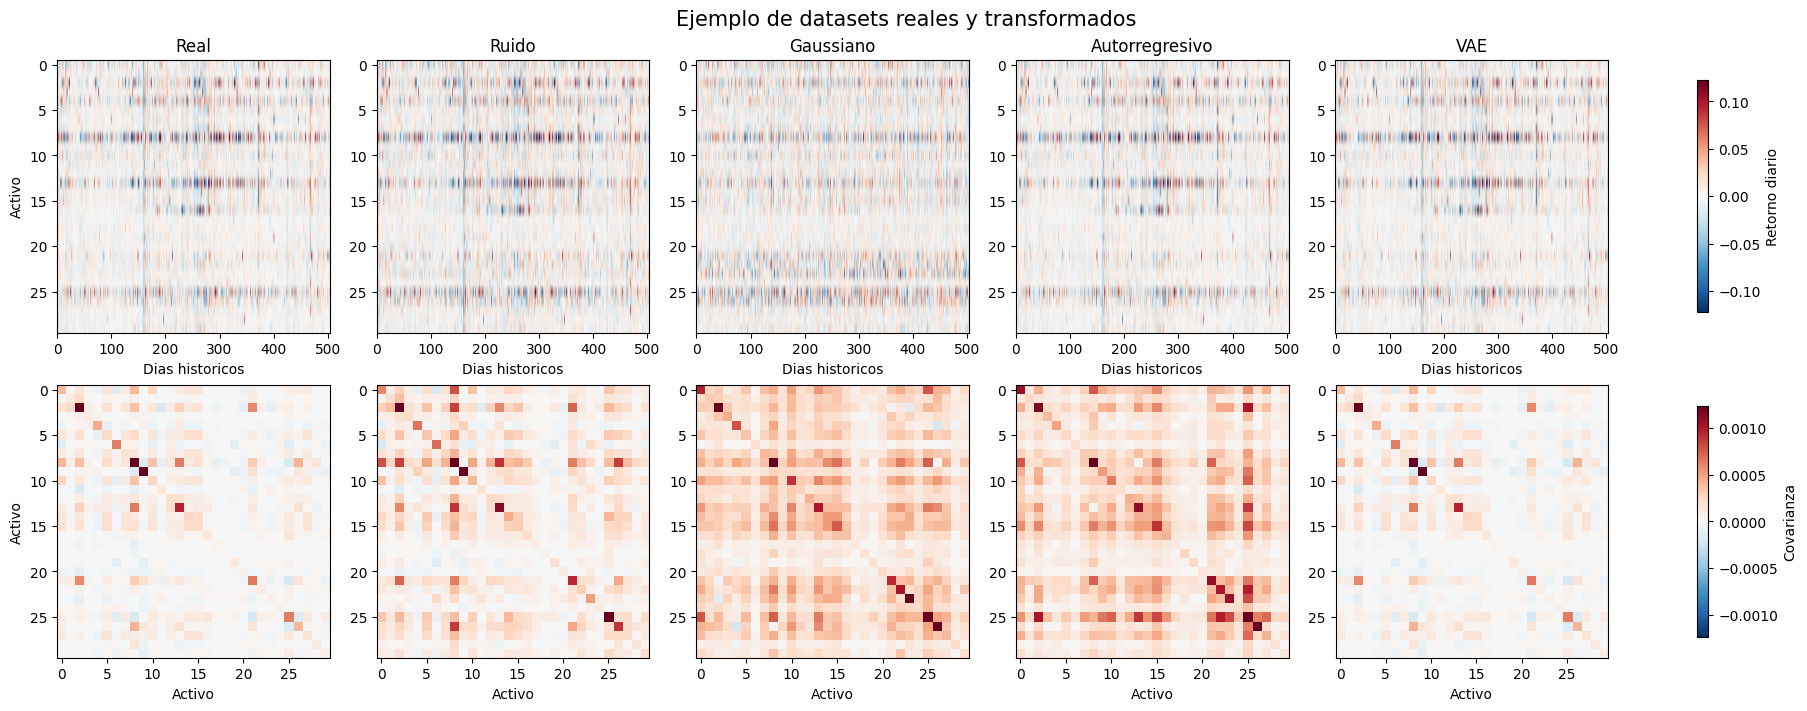

Figura guardada en: ..\reports\figures\07_datasets_transformados_ejemplo.png


In [71]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

DATASET_DIR = Path("../data/processed/combined_datasets")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

archivos = {
    "Real": "solo_real.npz",
    "Ruido": "real_mas_noise.npz",
    "Gaussiano": "real_mas_gaussian.npz",
    "Autorregresivo": "real_mas_ar.npz",
    "VAE": "real_mas_vae.npz",
}

datos = {nombre: np.load(DATASET_DIR / archivo) for nombre, archivo in archivos.items()}
n_reales = datos["Real"]["X"].shape[0]
ejemplos = {}
for nombre, dataset in datos.items():
    indice = 0 if nombre == "Real" else n_reales
    ejemplos[nombre] = (dataset["X"][indice], dataset["y"][indice])

limite_x = max(np.quantile(np.abs(x), 0.995) for x, _ in ejemplos.values())
limite_y = max(np.quantile(np.abs(y), 0.995) for _, y in ejemplos.values())
norm_x = TwoSlopeNorm(vmin=-limite_x, vcenter=0, vmax=limite_x)
norm_y = TwoSlopeNorm(vmin=-limite_y, vcenter=0, vmax=limite_y)

fig, axes = plt.subplots(2, len(ejemplos), figsize=(18, 7), constrained_layout=True)
for columna, (nombre, (x, y)) in enumerate(ejemplos.items()):
    im_x = axes[0, columna].imshow(x.T, aspect="auto", cmap="RdBu_r", norm=norm_x)
    im_y = axes[1, columna].imshow(y, aspect="equal", cmap="RdBu_r", norm=norm_y)
    axes[0, columna].set_title(nombre)
    axes[0, columna].set_xlabel("Dias historicos")
    axes[1, columna].set_xlabel("Activo")
    if columna == 0:
        axes[0, columna].set_ylabel("Activo")
        axes[1, columna].set_ylabel("Activo")

fig.colorbar(im_x, ax=axes[0, :], shrink=0.85, label="Retorno diario")
fig.colorbar(im_y, ax=axes[1, :], shrink=0.85, label="Covarianza")
fig.suptitle("Ejemplo de datasets reales y transformados", fontsize=15)
ruta_figura = FIG_DIR / "07_datasets_transformados_ejemplo.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {ruta_figura}")

## 11. Series transformadas superpuestas con las originales

Se muestran tres ejemplos de `AAPL` con cada metodo generativo. Ruido y Gaussiano se comparan sobre la misma ventana historica; para VAE se incluye un ejemplo de cada modelo de 5, 7 y 10 dias; el autorregresivo se compara con el futuro real de 42 dias desde un mismo punto de origen. Cada figura se muestra y se guarda en `reports/figures/series_transformadas/`.

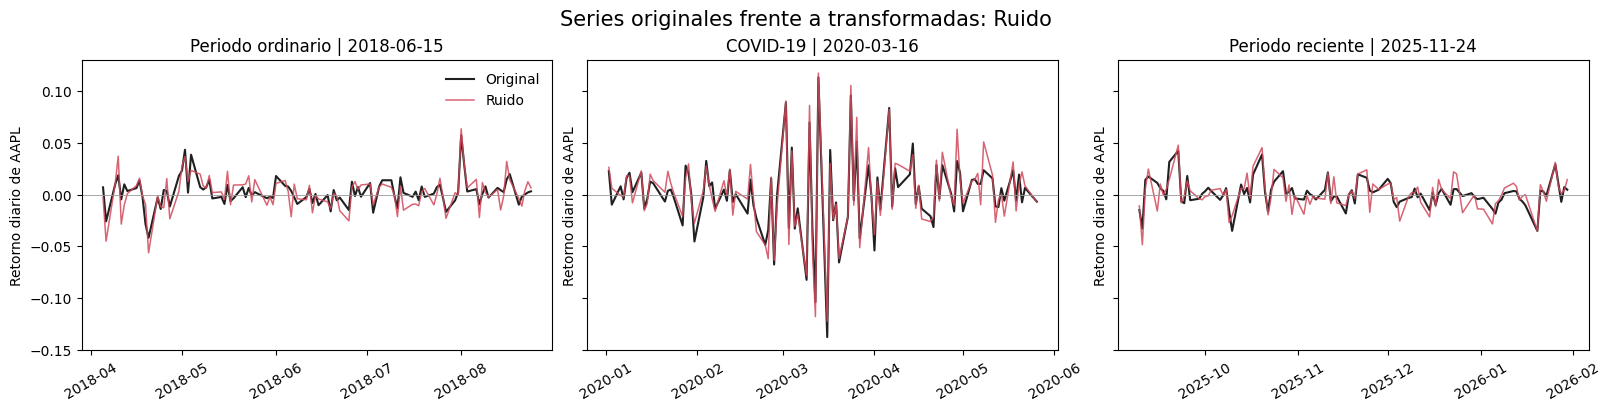

Figura guardada en: ..\reports\figures\series_transformadas\07_series_ruido_aapl.png


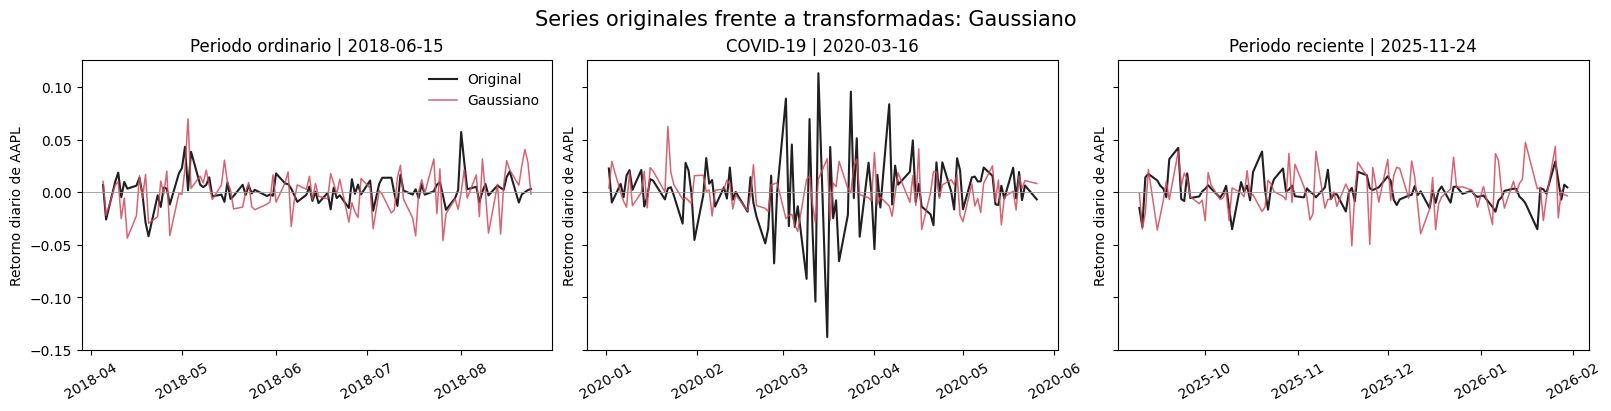

Figura guardada en: ..\reports\figures\series_transformadas\07_series_gaussiano_aapl.png


In [72]:
import matplotlib.pyplot as plt

SERIES_FIG_DIR = Path("../reports/figures/series_transformadas")
SERIES_FIG_DIR.mkdir(parents=True, exist_ok=True)
ACCION = "AAPL"
N_EJEMPLOS = 3
DIAS_VISIBLES = 100
ETIQUETAS_PERIODOS = ["Periodo ordinario", "COVID-19", "Periodo reciente"]
FECHAS_CENTRALES = pd.to_datetime(["2018-06-15", "2020-03-16", "2025-11-24"])

def intervalo_centrado(indice, fecha_central, n_dias):
    centro = indice.get_indexer([fecha_central], method="nearest")[0]
    inicio = max(0, centro - n_dias // 2)
    fin = min(len(indice), inicio + n_dias)
    inicio = max(0, fin - n_dias)
    return indice[inicio:fin]

def graficar_series_superpuestas(nombre, serie_sintetica, sufijo):
    fig, axes = plt.subplots(1, N_EJEMPLOS, figsize=(16, 4), sharey=True, squeeze=False, constrained_layout=True)
    for columna, (etiqueta, fecha_central) in enumerate(zip(ETIQUETAS_PERIODOS, FECHAS_CENTRALES)):
        fechas = intervalo_centrado(returns_real.index, fecha_central, DIAS_VISIBLES)
        axis = axes[0, columna]
        axis.plot(fechas, returns_real.loc[fechas, ACCION], color="#202020", lw=1.5, label="Original")
        axis.plot(fechas, serie_sintetica.loc[fechas, ACCION], color="#d1495b", lw=1.1, alpha=0.85, label=nombre)
        axis.axhline(0, color="#999999", lw=0.6)
        axis.set_title(f"{etiqueta} | {fecha_central.date()}")
        axis.set_ylabel("Retorno diario de AAPL")
        axis.tick_params(axis="x", rotation=30)
        if columna == 0:
            axis.legend(frameon=False)
    fig.suptitle(f"Series originales frente a transformadas: {nombre}", fontsize=15)
    ruta = SERIES_FIG_DIR / f"07_series_{sufijo}_aapl.png"
    fig.savefig(ruta, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada en: {ruta}")

graficar_series_superpuestas("Ruido", returns_noise, "ruido")
graficar_series_superpuestas("Gaussiano", returns_gaussian, "gaussiano")

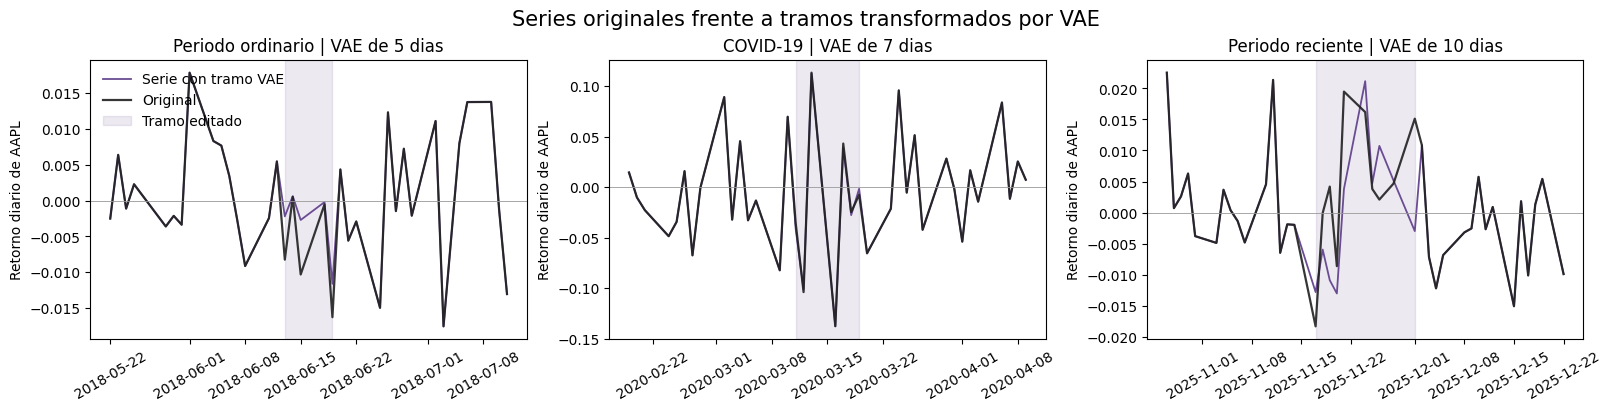

Figura guardada en: ..\reports\figures\series_transformadas\07_series_vae_aapl.png


In [73]:
VENTANAS_VAE = [5, 7, 10]
fig, axes = plt.subplots(1, len(VENTANAS_VAE), figsize=(16, 4), sharey=False, squeeze=False, constrained_layout=True)
for columna, (etiqueta, fecha_central, window_size) in enumerate(zip(ETIQUETAS_PERIODOS, FECHAS_CENTRALES, VENTANAS_VAE)):
    centro = components.index.get_indexer([fecha_central], method="nearest")[0]
    inicio_bloque = centro - window_size // 2
    segmento_real = components.iloc[inicio_bloque:inicio_bloque + window_size]
    vae_info = vae_models[window_size]
    segmento_norm = vae_info["scaler"].transform(segmento_real.to_numpy()).astype(np.float32)
    variante = decode_latent_variants(vae_info["model"], segmento_norm, [VAE_ALPHA], seed=2026 + columna, device=DEVICE)[VAE_ALPHA]
    variante_denorm = vae_info["scaler"].inverse_transform(variante)
    frame = pd.DataFrame(variante_denorm, index=segmento_real.index, columns=feature_names)
    mkt, sec, idio = split_components(frame)
    retornos_vae = reconstruct_returns(mkt, sec, idio, betas)

    inicio_vista = max(0, inicio_bloque - 15)
    fin_vista = min(len(returns_real), inicio_bloque + window_size + 15)
    fechas = returns_real.index[inicio_vista:fin_vista]
    serie_transformada = returns_real.loc[fechas, ACCION].copy()
    serie_transformada.loc[retornos_vae.index] = retornos_vae[ACCION]
    axis = axes[0, columna]
    axis.plot(fechas, serie_transformada, color="#6a4c93", lw=1.3, label="Serie con tramo VAE")
    axis.plot(fechas, returns_real.loc[fechas, ACCION], color="#202020", lw=1.6, alpha=0.9, label="Original")
    axis.axvspan(retornos_vae.index[0], retornos_vae.index[-1], color="#6a4c93", alpha=0.12, label="Tramo editado" if columna == 0 else None)
    axis.axhline(0, color="#999999", lw=0.6)
    axis.set_title(f"{etiqueta} | VAE de {window_size} dias")
    axis.set_ylabel("Retorno diario de AAPL")
    axis.tick_params(axis="x", rotation=30)
    if columna == 0:
        axis.legend(frameon=False)
fig.suptitle("Series originales frente a tramos transformados por VAE", fontsize=15)
ruta_vae = SERIES_FIG_DIR / "07_series_vae_aapl.png"
fig.savefig(ruta_vae, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {ruta_vae}")

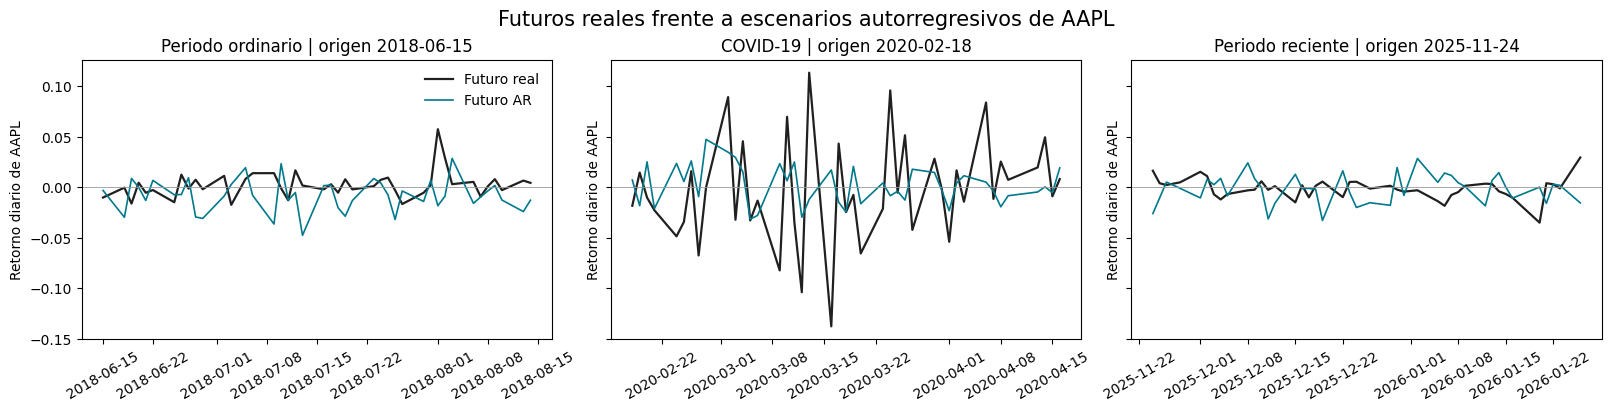

Figura guardada en: ..\reports\figures\series_transformadas\07_series_autoregresivo_aapl.png


In [74]:
FECHAS_ORIGEN_AR = pd.to_datetime(["2018-06-15", "2020-02-18", "2025-11-24"])
fig, axes = plt.subplots(1, N_EJEMPLOS, figsize=(16, 4), sharey=True, squeeze=False, constrained_layout=True)
for columna, (etiqueta, fecha_solicitada) in enumerate(zip(ETIQUETAS_PERIODOS, FECHAS_ORIGEN_AR)):
    posicion_origen = components.index.get_indexer([fecha_solicitada], method="nearest")[0]
    fecha_origen = components.index[posicion_origen]
    contexto = components.iloc[posicion_origen - AR_CONTEXT_LENGTH:posicion_origen]
    contexto_norm = ar_scaler.transform(contexto.to_numpy()).astype(np.float32)
    componentes_ar, _, _ = generate_multihorizon_rolling_batch(
        ar_model, contexto_norm, generation_horizon=HORIZON_DAYS,
        temperature=1.0, n_paths=1, seed=2026 + columna, device=DEVICE,
    )
    camino_denorm = ar_scaler.inverse_transform(componentes_ar[0])
    frame = pd.DataFrame(camino_denorm, columns=feature_names)
    mkt, sec, idio = split_components(frame)
    retorno_generado = reconstruct_returns(mkt, sec, idio, betas)

    fechas_futuras = returns_real.index[posicion_origen:posicion_origen + HORIZON_DAYS]
    futuro_real = returns_real.iloc[posicion_origen:posicion_origen + HORIZON_DAYS]
    axis = axes[0, columna]
    axis.plot(fechas_futuras, futuro_real[ACCION].to_numpy(), color="#202020", lw=1.6, label="Futuro real")
    axis.plot(fechas_futuras, retorno_generado[ACCION].to_numpy(), color="#00798c", lw=1.2, label="Futuro AR")
    axis.axhline(0, color="#999999", lw=0.6)
    axis.set_title(f"{etiqueta} | origen {fecha_origen.date()}")
    axis.set_ylabel("Retorno diario de AAPL")
    axis.tick_params(axis="x", rotation=30)
    if columna == 0:
        axis.legend(frameon=False)
fig.suptitle("Futuros reales frente a escenarios autorregresivos de AAPL", fontsize=15)
ruta_ar = SERIES_FIG_DIR / "07_series_autoregresivo_aapl.png"
fig.savefig(ruta_ar, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {ruta_ar}")

## Conclusión y siguiente paso

Seis datasets de entrenamiento listos para el predictor de covarianzas:
`solo_real` (equivalente a entrenar solo con datos reales, como
referencia), y cinco variantes aumentadas con sintéticos — incluyendo ya
los 4 generadores del proyecto (ruido, Gaussiana, VAE, autorregresivo),
cada uno usado según su diseño (AR generando futuros alternativos, VAE
editando tramos de la historia). La validación y el test son siempre los
mismos 100% reales, así que las seis variantes son directamente
comparables entre sí — la única diferencia es qué vio el modelo durante
el entrenamiento.

**Siguiente paso:** entrenar la misma arquitectura del predictor de
covarianzas sobre cada una de estas seis variantes y comparar el error de
test, para responder con datos si algún sintético (o su combinación)
ayuda a superar el baseline.